In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
digits = load_digits()
cancer = load_breast_cancer()

print("MNIST Dataset Shape:", digits.data.shape)
print("Feature Names (first 10):", digits.feature_names[:10])
print("Sample Output:", digits.target[:10])

print("\nCancer Dataset Shape:", cancer.data.shape)
print("Feature Names:", cancer.feature_names)
print("Sample Output:", cancer.target[:10])

MNIST Dataset Shape: (1797, 64)
Feature Names (first 10): ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1']
Sample Output: [0 1 2 3 4 5 6 7 8 9]

Cancer Dataset Shape: (569, 30)
Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Sample Output: [0 0 0 0 0 0 0 0 0 0]


In [3]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42)

print("MNIST Train Shape:", X_train_d.shape)
print("MNIST Test Shape:", X_test_d.shape)

print("Cancer Train Shape:", X_train_c.shape)
print("Cancer Test Shape:", X_test_c.shape)

MNIST Train Shape: (1257, 64)
MNIST Test Shape: (540, 64)
Cancer Train Shape: (398, 30)
Cancer Test Shape: (171, 30)


In [4]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_c, y_train_c)

y_pred_lr = lr.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_lr))

cm_lr = confusion_matrix(y_test_c, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

Accuracy: 0.9766081871345029
Confusion Matrix:
 [[ 61   2]
 [  2 106]]


In [5]:
print(classification_report(y_test_c, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [6]:
lr_mnist = LogisticRegression(max_iter=5000)
lr_mnist.fit(X_train_d, y_train_d)

y_pred_mnist = lr_mnist.predict(X_test_d)

print("MNIST Accuracy (Logistic):", accuracy_score(y_test_d, y_pred_mnist))

MNIST Accuracy (Logistic): 0.9685185185185186


In [7]:
svm = SVC()
svm.fit(X_train_c, y_train_c)

y_pred_svm = svm.predict(X_test_c)

print("SVM Accuracy:", accuracy_score(y_test_c, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_svm))

SVM Accuracy: 0.935672514619883
Confusion Matrix:
 [[ 52  11]
 [  0 108]]


In [8]:
svm_mnist = SVC()
svm_mnist.fit(X_train_d, y_train_d)

y_pred_svm_mnist = svm_mnist.predict(X_test_d)

print("MNIST Accuracy (SVM):", accuracy_score(y_test_d, y_pred_svm_mnist))

MNIST Accuracy (SVM): 0.987037037037037


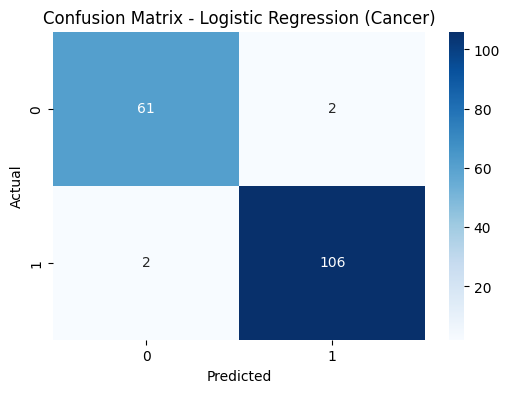

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Cancer)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
print("Logistic Regression Accuracy:", accuracy_score(y_test_c, y_pred_lr))
print("SVM Accuracy:", accuracy_score(y_test_c, y_pred_svm))

Logistic Regression Accuracy: 0.9766081871345029
SVM Accuracy: 0.935672514619883


In [11]:
# Conclusion:
# Logistic Regression is fast, simple, and works well for basic problems,
# while SVM provides better accuracy for complex data but is slower.
# Data splitting helps evaluate models properly, and F1-score is more reliable
# than accuracy in many cases. Model choice depends on data complexity.